# Fase 1: Carregamento e Análise Exploratória de Imagens (EDA)

## 1.1. Importações e Download

In [1]:
import os
import glob

from sklearn.metrics import accuracy_score
import time

from src.data import load_mnist
from src.eda import resumo_shapes, distribuicao_classes
from src.visualize import plot_digito, plot_distribuicao, plot_grade_digitos, plot_previsao_digito, plot_matriz_confusao, plot_confianca
from src.preprocessing import split_treino_teste, normalizar_pixels, remover_classes, selecionar_classes
from src.manuscript import preprocessar_imagem_propria
from src.models import (get_knn, buscar_melhor_knn, get_random_forest, buscar_melhor_random_forest, get_mlp, buscar_melhor_mlp,)
from src.model_cache import obter_ou_buscar_modelo, salvar_metricas_modelo, salvar_modelo
from src.evaluation import calcular_metricas, montar_tabela_comparativa, gerar_conclusao_tecnica
from config.config import DIR_IMAGENS_PROPRIAS

In [2]:
# Baixando o MNIST oficial do OpenML
print("Baixando o dataset MNIST...")
X, y = load_mnist()
print("Download do dataset MNIST finalizado!")

Baixando o dataset MNIST...
Download do dataset MNIST finalizado!


## 1.2. Dimensionalidade das Matrizes (X e y)

In [3]:
# Mostra um número aleatório do dataset
X[700] 

array([  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,  98, 224,  42,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  3

In [4]:
# Mostra os resultados do dataset (rótulos/targets das imgs)
y

array([5, 0, 4, ..., 4, 5, 6], dtype=uint8)

In [5]:
resumo_shapes(X, y)

Formato de X (amostras, pixels por imagem): (70000, 784)
Formato de y (rótulos): (70000,)
Classes únicas existentes: [0 1 2 3 4 5 6 7 8 9]


A escala de intensidade dos pixels em imagens em tons de cinza varia de 0 a 255, onde o valor 0 representa a cor preta e o valor 255 representa a cor branca. Os valores intermediários representam diferentes tons de cinza, sendo que quanto maior o valor, mais claro é o pixel. No conjunto de dados MNIST, cada imagem possui dimensões de 28 × 28 pixels, totalizando 784 pixels por imagem, pois 28 * 28 = 784. Inicialmente, a imagem é representada como uma matriz bidimensional (28 × 28), em que cada posição contém o valor de intensidade de um pixel. Para utilizar a imagem em determinados algoritmos de aprendizado de máquina, essa matriz pode ser transformada em um vetor unidimensional por meio do processo chamado flattening (achatamento). Dessa forma, os 784 pixels passam a ser representados como 784 features, sendo que cada feature corresponde à intensidade de um determinado pixel, com valores entre 0 e 255.

![Explicação MNIST](images/explicacao_mnist.png)

## 1.3. Distribuição das Classes

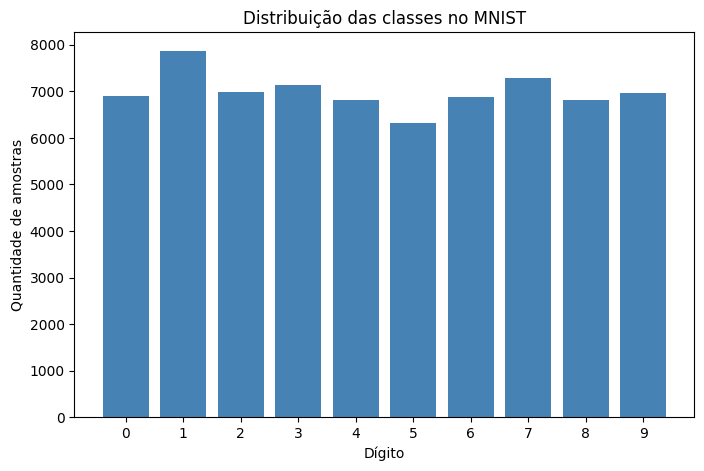

In [6]:
# Conta quantas amostras existem de cada dígito 
classes, contagens = distribuicao_classes(y)
plot_distribuicao(classes, contagens)

## 1.4. Grade Visual

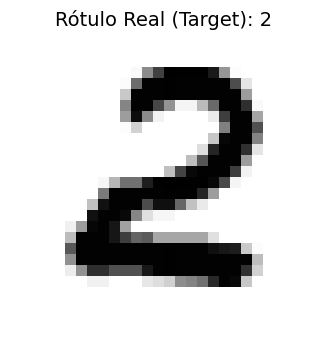

In [7]:
# Visualiuzando uma imagem do dataset
indice = 65643
plot_digito(X, y, indice)

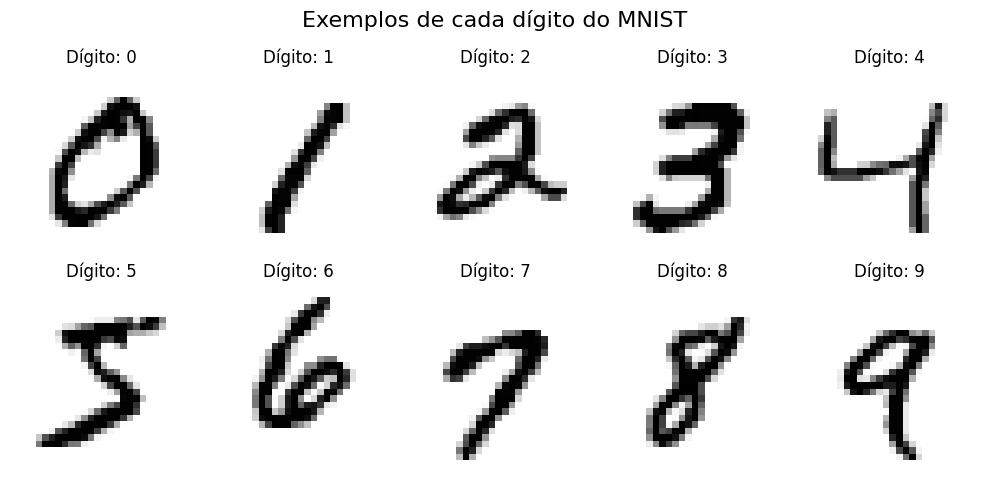

In [8]:
plot_grade_digitos(X, y)

# Fase 2: Divisão dos Dados

## 2.1. Split Treino (80%) e Teste (20%)

In [9]:
# Divide em 80% treino e 20% teste, de forma estratificada por classe
X_train, X_test, y_train, y_test = split_treino_teste(X, y, test_size=0.2, random_state=42)

print("Formato de X_train:", X_train.shape)
print("Formato de X_test:", X_test.shape)
print("Formato de y_train:", y_train.shape)
print("Formato de y_test:", y_test.shape)

Formato de X_train: (56000, 784)
Formato de X_test: (14000, 784)
Formato de y_train: (56000,)
Formato de y_test: (14000,)


## 2.2. Normalização dos Pixels

In [10]:
# Redimensiona os valores de pixel de [0, 255] para a escala [0.0, 1.0]
X_train, X_test = normalizar_pixels(X_train, X_test)

print("Valor mínimo em X_train:", X_train.min())
print("Valor máximo em X_train:", X_train.max())

Valor mínimo em X_train: 0.0
Valor máximo em X_train: 1.0


**Distâncias métricas:** Modelos que calculam distâncias geométricas (como a Euclidiana) falham se os atributos tiverem escalas altas, pois pixels maiores dominam o cálculo da proximidade entre os dígitos.

**Convergência :** Algoritmos baseados em gradiente ajustam seus pesos buscando o menor erro possível. Valores uniformes entre `0.0` e `1.0` estabilizam a superfície de aprendizado, evitando saltos desproporcionais e permitindo que o modelo **converja muito mais rápido** para o resultado correto.

# Fase 3: Implementação e Treinamento dos 3 Modelos

Os melhores hiperparâmetros de cada modelo, encontrados via `GridSearchCV`, são salvos em `config/melhores_hiperparametros.json`. Ao rodar o notebook novamente, cada modelo é recriado direto a partir desses hiperparâmetros salvos (sem repetir a busca).

## 3.1. KNN (K-Nearest Neighbors)

**Hiperparâmetro `n_neighbors`:** quantidade de vizinhos mais próximos consultados para classificar uma imagem;

**Hiperparâmetro `weights`:** forma de ponderar o voto dos vizinhos. 'uniform' dá peso
      igual a todos; 'distance' dá mais peso aos vizinhos mais próximos.

Abaixo foi utilizado `GridSearchCV` para testar várias combinações de `n_neighbors` e `weights` com validação cruzada e escolher automaticamente a combinação com melhor acurácia média nos dados de treino.

In [11]:
buscar_novamente_knn = False  # True para rodar o GridSearchCV 

knn, melhores_params_knn, tempo_treino_knn = obter_ou_buscar_modelo(
    'knn', get_knn, buscar_melhor_knn, X_train, y_train,
    buscar_novamente=buscar_novamente_knn,
)
print("Melhores hiperparâmetros do KNN:", melhores_params_knn)

y_pred_knn = knn.predict(X_test)
print("Acurácia do KNN no conjunto de teste:", accuracy_score(y_test, y_pred_knn))
print("Tempo de treino do KNN (s):", tempo_treino_knn)

Melhores hiperparâmetros do KNN: {'n_neighbors': 6, 'weights': 'distance'}
Acurácia do KNN no conjunto de teste: 0.9708571428571429
Tempo de treino do KNN (s): 0.006888151168823242


## 3.2. Random Forest

**Hiperparâmetro `n_estimators`:** número de árvores de decisão no ensemble;

**Hiperparâmetro `max_depth`:** profundidade máxima de cada árvore.

Abaixo foi utilizado o `GridSearchCV` para testar várias combinações de `n_estimators` e `max_depth` com validação cruzada e escolher automaticamente a combinação com melhor acurácia média nos dados de treino.

In [12]:
buscar_novamente_rf = False  # True para rodar o GridSearchCV 

rf, melhores_params_rf, tempo_treino_rf = obter_ou_buscar_modelo(
    'random_forest', get_random_forest, buscar_melhor_random_forest, X_train, y_train,
    buscar_novamente=buscar_novamente_rf,
)
print("Melhores hiperparâmetros da Random Forest:", melhores_params_rf)

y_pred_rf = rf.predict(X_test)
print("Acurácia do Random Forest no conjunto de teste:", accuracy_score(y_test, y_pred_rf))
print("Tempo de treino da Random Forest (s):", tempo_treino_rf)

Melhores hiperparâmetros da Random Forest: {'max_depth': None, 'n_estimators': 300}
Acurácia do Random Forest no conjunto de teste: 0.9680714285714286
Tempo de treino da Random Forest (s): 44.301554918289185


## 3.3. MLP (Perceptron Multicamadas)

**Hiperparâmetro `hidden_layer_sizes`:** quantidade de neurônios em cada camada oculta;

**Hiperparâmetro `learning_rate_init`:** taxa de aprendizado inicial do otimizador baseado em gradiente.

Abaixo foi utilizado `GridSearchCV` para testar várias combinações de `hidden_layer_sizes` e `learning_rate_init` com validação cruzada e escolher automaticamente a combinação com melhor acurácia média nos dados de treino.

In [13]:
buscar_novamente_mlp = False  # True para rodar o GridSearchCV 

mlp, melhores_params_mlp, tempo_treino_mlp = obter_ou_buscar_modelo(
    'mlp', get_mlp, buscar_melhor_mlp, X_train, y_train,
    buscar_novamente=buscar_novamente_mlp,
)
print("Melhores hiperparâmetros do MLP:", melhores_params_mlp)

y_pred_mlp = mlp.predict(X_test)
print("Acurácia do MLP no conjunto de teste:", accuracy_score(y_test, y_pred_mlp))
print("Tempo de treino do MLP (s):", tempo_treino_mlp)

/Users/jenifer/Documents/SCTEC-Mini-Projeto-MD2/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/jenifer/Documents/SCTEC-Mini-Projeto-MD2/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/jenifer/Documents/SCTEC-Mini-Projeto-MD2/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


Melhores hiperparâmetros do MLP: {'hidden_layer_sizes': [128, 64], 'learning_rate_init': 0.001}
Acurácia do MLP no conjunto de teste: 0.9803571428571428
Tempo de treino do MLP (s): 8.936262845993042


/Users/jenifer/Documents/SCTEC-Mini-Projeto-MD2/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/jenifer/Documents/SCTEC-Mini-Projeto-MD2/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/jenifer/Documents/SCTEC-Mini-Projeto-MD2/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


# Fase 4: Avaliação Comparativa de Desempenho

## 4.1. Matrizes de Confusão

OBS: A diagonal principal mostra os acertos por dígito, e as células fora da diagonal mostram para qual dígito cada erro foi classificado.

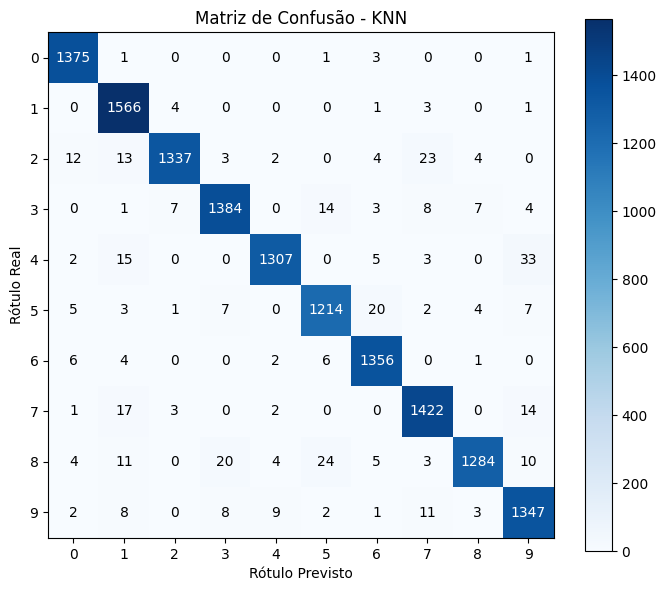

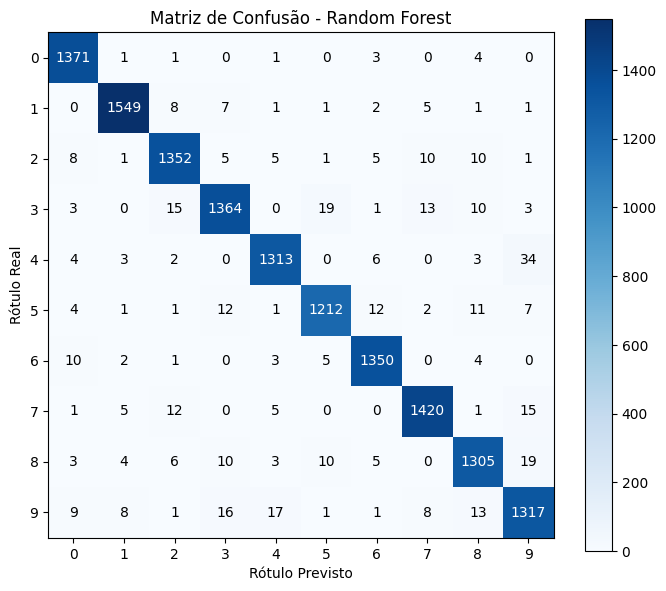

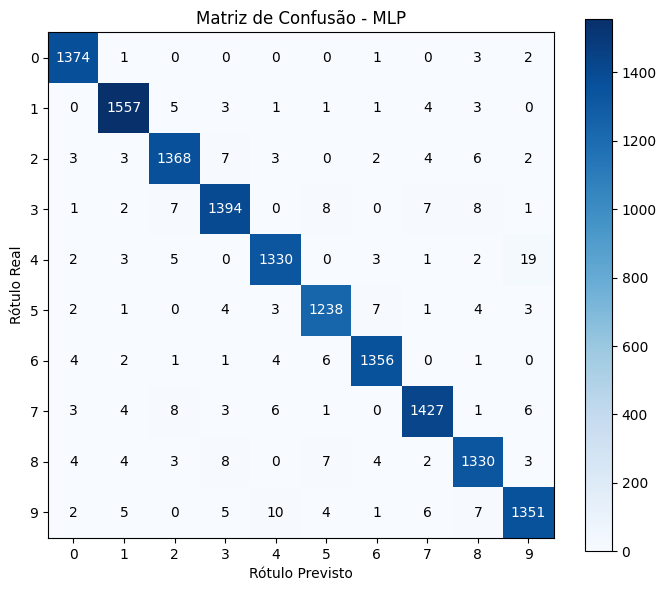

In [14]:
matriz_knn = plot_matriz_confusao(y_test, y_pred_knn, "KNN")
matriz_rf  = plot_matriz_confusao(y_test, y_pred_rf, "Random Forest")
matriz_mlp = plot_matriz_confusao(y_test, y_pred_mlp, "MLP")

## 4.2. Tabela Comparativa de Métricas

Para cada modelo, foram calculadas as métricas:
- Acurácia Global (Accuracy)
- Precisão Média Ponderada (Precision)
- Revocação/Sensibilidade Média Ponderada (Recall)
- Fl-Score Ponderado (Fl-Score)

Também foi calculado o tempo de treino de cada modelo.

In [15]:
metricas_knn = calcular_metricas(y_test, y_pred_knn, "KNN", tempo_treino=tempo_treino_knn)
metricas_rf  = calcular_metricas(y_test, y_pred_rf, "Random Forest", tempo_treino=tempo_treino_rf)
metricas_mlp = calcular_metricas(y_test, y_pred_mlp, "MLP", tempo_treino=tempo_treino_mlp)

salvar_metricas_modelo(metricas_knn, 'knn')
salvar_metricas_modelo(metricas_rf, 'random_forest')
salvar_metricas_modelo(metricas_mlp, 'mlp')

tabela_comparativa = montar_tabela_comparativa([metricas_knn, metricas_rf, metricas_mlp])
tabela_comparativa

,Acurácia,Precisão (ponderada),Revocação (ponderada),F1-Score (ponderado),Tempo de Treino (s)
Modelo,,,,,
KNN,0.9709,0.9711,0.9709,0.9708,0.0069
Random Forest,0.9681,0.9681,0.9681,0.9681,44.3016
MLP,0.9804,0.9803,0.9804,0.9803,8.9363


## 4.3. Conclusão Técnica

In [16]:
previsoes = {
    "KNN": y_pred_knn,
    "Random Forest": y_pred_rf,
    "MLP": y_pred_mlp,
}

print(gerar_conclusao_tecnica(tabela_comparativa, y_test, previsoes))

Confusão mais frequente por modelo:
- KNN: dígito real 4 classificado como 9 em 33 casos.
- Random Forest: dígito real 4 classificado como 9 em 34 casos.
- MLP: dígito real 4 classificado como 9 em 19 casos.

Menor custo computacional de treino: KNN, treinado em 0.01s.


O MLP (Perceptron Multicamadas)** obteve melhor performance em todas as métricas.

* **KNN:** Menor tempo de treino absoluto ($\approx 0,0071\text{ s}$), excelente acurácia ($97,09\%$) e melhor relação custo-benefício para máxima velocidade.
* **MLP:** Maior acurácia global ($\approx 98,04\%$) e melhor equilíbrio geral nas métricas ponderadas, com tempo de treino intermediário ($\approx 9,01\text{ s}$).
* **Random Forest:** Maior custo computacional de treinamento ($\approx 45,38\text{ s}$) devido às árvores de decisão, mas entregou a menor acurácia do trio ($96,81\%$).

O MLP justifica-se pelo ganho em acurácia, enquanto o KNN destaca-se pela extrema leveza operacional com perda mínima de desempenho.

# Fase 5 - Cenários fora do padrão ideal de laboratório

## Fase 5.1 - Desafio (A) Treinamento Restrito com Classes Ocultadas (Class Masking)

Selecionada duas classes para serem totalmente removidas da base de
treinamento e depois treina a rede neural sem essas classes.

In [17]:
classes_ocultadas = [4, 7]  # Dígitos a serem removidos do treino

X_train_mascarado, y_train_mascarado = remover_classes(X_train, y_train, classes_ocultadas)

print("Classes ocultadas do treino:", classes_ocultadas)
print("Formato de X_train original:", X_train.shape)
print("Formato de X_train sem as classes ocultadas:", X_train_mascarado.shape)
print("Classes presentes no treino mascarado:", sorted(int(c) for c in set(y_train_mascarado)))


Classes ocultadas do treino: [4, 7]
Formato de X_train original: (56000, 784)
Formato de X_train sem as classes ocultadas: (44707, 784)
Classes presentes no treino mascarado: [0, 1, 2, 3, 5, 6, 8, 9]


In [18]:
# Reaproveita os hiperparâmetros salvos
mlp_mascarado = get_mlp(**melhores_params_mlp)

# Treina MLP com as classes ocultadas
inicio = time.time()
mlp_mascarado.fit(X_train_mascarado, y_train_mascarado)
tempo_treino_mlp_mascarado = time.time() - inicio

salvar_modelo(mlp_mascarado, 'mlp_class_masking')

print("Hiperparâmetros usados:", melhores_params_mlp)
print("Tempo de treino do MLP com class masking (s):", tempo_treino_mlp_mascarado)

/Users/jenifer/Documents/SCTEC-Mini-Projeto-MD2/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/jenifer/Documents/SCTEC-Mini-Projeto-MD2/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/jenifer/Documents/SCTEC-Mini-Projeto-MD2/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


Hiperparâmetros usados: {'hidden_layer_sizes': [128, 64], 'learning_rate_init': 0.001}
Tempo de treino do MLP com class masking (s): 6.506588935852051


## Fase 5.2 - Desafio (B) Teste de Generalização Extrema (Inferência OOD)

Abaixo o MLP que fora treinado sem os dígitos ocultados,  é submetido a um conjunto de teste contendo exclusivamente esses dígitos.

Formato do conjunto de teste apenas com as classes ocultadas: (2824, 784)
Classes presentes no conjunto de teste ocultado: [4, 7]
Acurácia do MLP mascarado nas classes nunca vistas: 0.0


/Users/jenifer/Documents/SCTEC-Mini-Projeto-MD2/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/jenifer/Documents/SCTEC-Mini-Projeto-MD2/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/jenifer/Documents/SCTEC-Mini-Projeto-MD2/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


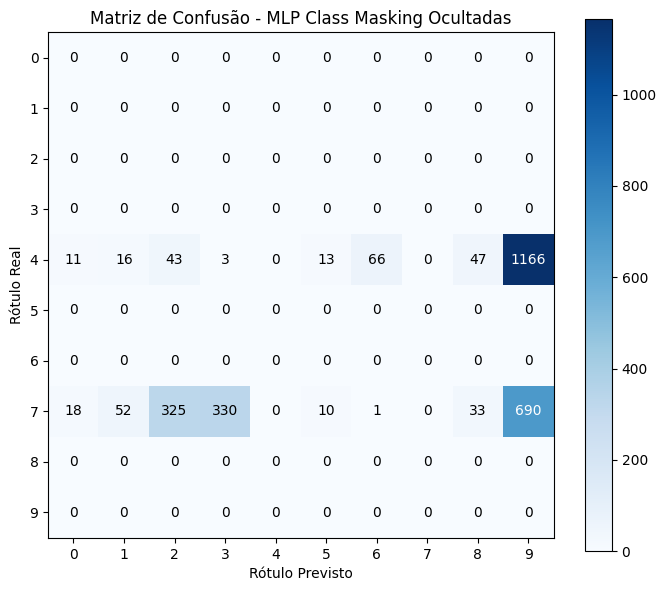

In [19]:
# Aqui no conjunto de teste ficará somente as classes ocultadas
X_test_ocultado, y_test_ocultado = selecionar_classes(X_test, y_test, classes_ocultadas)

print("Formato do conjunto de teste apenas com as classes ocultadas:", X_test_ocultado.shape)
print("Classes presentes no conjunto de teste ocultado:", sorted(int(c) for c in set(y_test_ocultado)))

# Faz previsão com o conjunto de teste que contém apenas as classes ocultadas
y_pred_ocultado = mlp_mascarado.predict(X_test_ocultado)

print("Acurácia do MLP mascarado nas classes nunca vistas:", accuracy_score(y_test_ocultado, y_pred_ocultado))

matriz_mlp_ocultado = plot_matriz_confusao(y_test_ocultado, y_pred_ocultado, "MLP Class Masking Ocultadas")

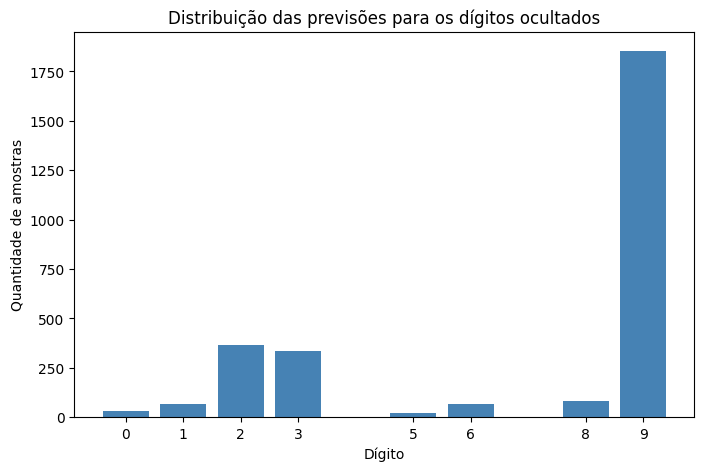

In [20]:
# Como o modelo nunca aprendeu esses dígitos, ele é forçado a classificar com o que ele já conhece
contagem_previsoes = {}
for rotulo in y_pred_ocultado:
    rotulo = int(rotulo)
    contagem_previsoes[rotulo] = contagem_previsoes.get(rotulo, 0) + 1

classes_previstas = sorted(contagem_previsoes)
contagens_previstas = [contagem_previsoes[c] for c in classes_previstas]

plot_distribuicao(
    classes_previstas, contagens_previstas,
    titulo="Distribuição das previsões para os dígitos ocultados",
    nome_arquivo='distribuicao_previsoes_class_masking.png',
)

Também é importante observar o quão confiante o MLP mascarado fica ao classificar os dígitos que ele nunca viu durante o treino, e comparar essa confiança com a que ele tem em dígitos conhecidos.

/Users/jenifer/Documents/SCTEC-Mini-Projeto-MD2/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/jenifer/Documents/SCTEC-Mini-Projeto-MD2/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/jenifer/Documents/SCTEC-Mini-Projeto-MD2/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


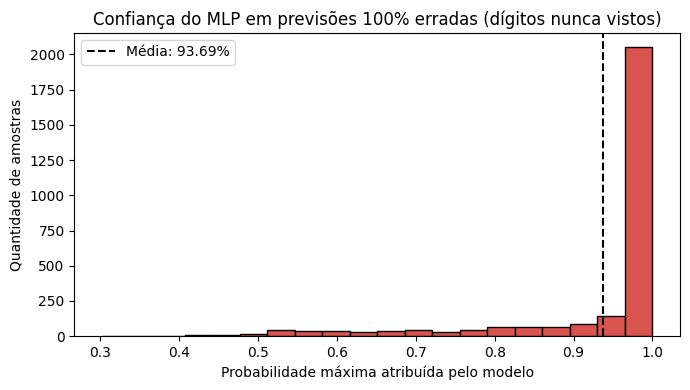

In [21]:
# Confiança (probabilidade máxima prevista) do MLP mascarado nas classes nunca vistas 
probas_ocultado = mlp_mascarado.predict_proba(X_test_ocultado)
confianca_ocultado = probas_ocultado.max(axis=1)

plot_confianca(
    confianca_ocultado,
    titulo="Confiança do MLP em previsões 100% erradas (dígitos nunca vistos)",
    nome_arquivo='confianca_class_masking_ocultado.png',
)

In [22]:
# Confiança do mesmo modelo nas classes que ele de fato conhece, para efeito de comparação
X_test_conhecido, y_test_conhecido = remover_classes(X_test, y_test, classes_ocultadas)

probas_conhecido = mlp_mascarado.predict_proba(X_test_conhecido)
confianca_conhecido = probas_conhecido.max(axis=1)

print("Confiança média do MLP em previsões de dígitos conhecidos:", confianca_conhecido.mean())
print("Confiança média do MLP em previsões de dígitos nunca vistos:", confianca_ocultado.mean())


Confiança média do MLP em previsões de dígitos conhecidos: 0.9951800152149973
Confiança média do MLP em previsões de dígitos nunca vistos: 0.9369143144114552


/Users/jenifer/Documents/SCTEC-Mini-Projeto-MD2/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/jenifer/Documents/SCTEC-Mini-Projeto-MD2/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/jenifer/Documents/SCTEC-Mini-Projeto-MD2/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


O MLP, mesmo nunca tendo visto os dígitos 4 e 7, não se recusa a classificá-los: como a softmax sempre normaliza as probabilidades entre as classes conhecidas, o modelo é obrigado a escolher uma das 8 classes aprendidas. Como nenhuma delas é a correta, a acurácia foi de 0% nas 2.824 amostras ocultadas — resultado esperado, já que o modelo nunca aprendeu esses padrões.

A matriz de confusão e a distribuição das previsões mostram que o erro não é aleatório: a maioria das imagens de 4 e 7 foi classificada como 9, o dígito conhecido visualmente mais parecido. Isso sugere que o modelo compara as features aprendidas com o que conhece e "arredonda" para a classe mais próxima.

O ponto mais crítico está na confiança das previsões (predict_proba): mesmo errando 100% das vezes nos dígitos ocultados, a probabilidade média atribuída foi de 93,69% — próxima dos 99,52% de confiança que o mesmo modelo tem ao acertar dígitos conhecidos. Isso evidencia numericamente a falsa certeza (overconfidence): a rede nunca aprende o conceito de "não sei", sempre entregando uma resposta de alta confiança, mesmo diante de algo totalmente fora do que ela conhece. Por isso os mecanismos de detecção de Out-of-Distribution (OOD) em aplicações reais são muito importantes.

## Fase 5.3 - Desafio (C) Inferência com Imagens Manuscritas Próprias

Pasta my_images possui as imagens manuscritas, onde:
- light: dígitos escritos à caneta preta e com fundo claro em papel;
- dark: dígitos brancos com fundo preto criados no Paint.


Realizado pré-procesamento:
1. Conversão para a escala de cinza;
2. Inversão de cores (caso light);
3. Remoção de sombras, cálculo de limiar de Otsu, bounding box do traço, centralização de massa em 28x28;
4. Normalização para o intervalo [0.0, 1.0].

Modelo selecionado é o MLP.

In [23]:
# Cada subpasta tem um tipo de pré-processamento
PASTAS_IMAGENS_PROPRIAS = {
    'light': True,   # papel branco, caneta escura
    'dark': False,   # fundo escuro, traço claro (padrão MNIST)
}

caminhos_imagens_proprias = [
    (caminho, traco_escuro)
    for subpasta, traco_escuro in PASTAS_IMAGENS_PROPRIAS.items()
    for caminho in sorted(glob.glob(os.path.join(DIR_IMAGENS_PROPRIAS, subpasta, '*')))
    if not caminho.lower().endswith('.md')
]

print(f"{len(caminhos_imagens_proprias)} imagem(ns) encontrada(s) em '{DIR_IMAGENS_PROPRIAS}'")

10 imagem(ns) encontrada(s) em '/Users/jenifer/Documents/SCTEC-Mini-Projeto-MD2/my_images'


/Users/jenifer/Documents/SCTEC-Mini-Projeto-MD2/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/jenifer/Documents/SCTEC-Mini-Projeto-MD2/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/jenifer/Documents/SCTEC-Mini-Projeto-MD2/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


2_light.jpeg -> previsto como 2 (confiança: 51.74%)


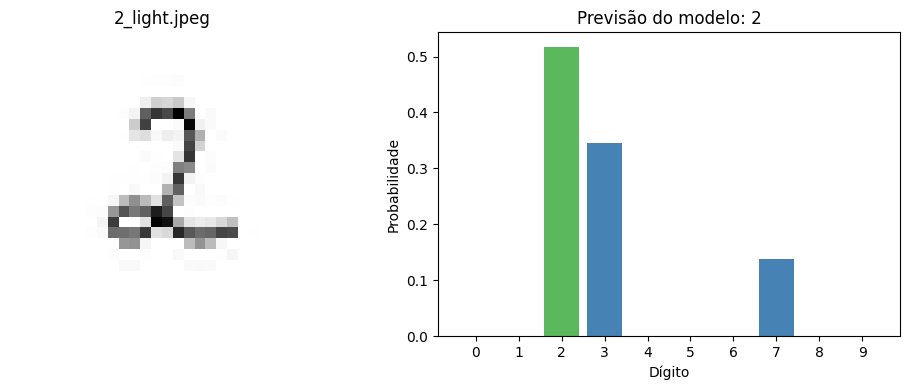

4_light.jpeg -> previsto como 4 (confiança: 99.99%)


/Users/jenifer/Documents/SCTEC-Mini-Projeto-MD2/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/jenifer/Documents/SCTEC-Mini-Projeto-MD2/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/jenifer/Documents/SCTEC-Mini-Projeto-MD2/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


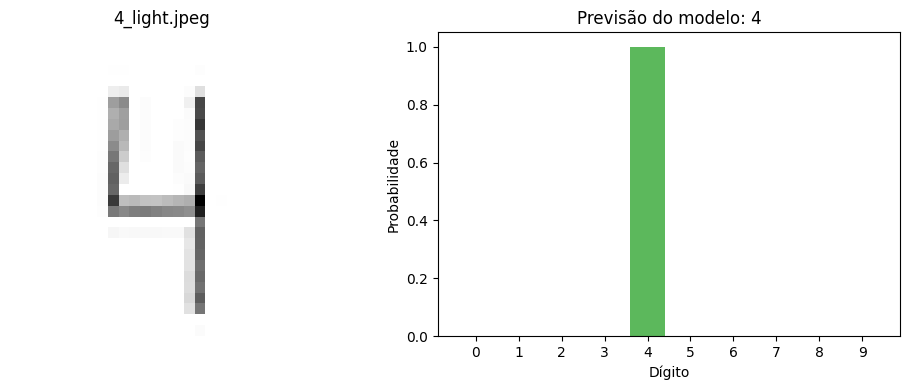

5_light.jpeg -> previsto como 5 (confiança: 99.44%)


/Users/jenifer/Documents/SCTEC-Mini-Projeto-MD2/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/jenifer/Documents/SCTEC-Mini-Projeto-MD2/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/jenifer/Documents/SCTEC-Mini-Projeto-MD2/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


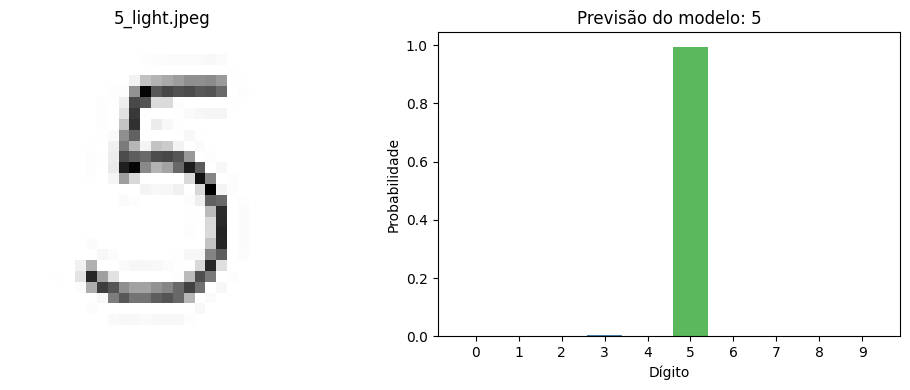

8_light.jpeg -> previsto como 8 (confiança: 99.91%)


/Users/jenifer/Documents/SCTEC-Mini-Projeto-MD2/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/jenifer/Documents/SCTEC-Mini-Projeto-MD2/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/jenifer/Documents/SCTEC-Mini-Projeto-MD2/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


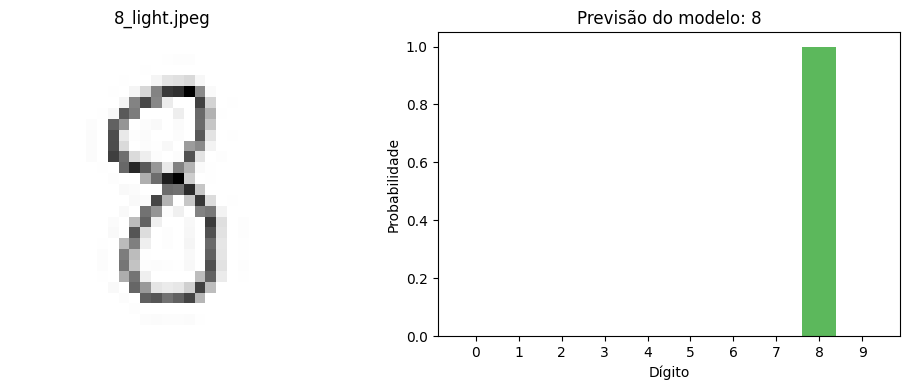

9_light.jpeg -> previsto como 9 (confiança: 50.61%)


/Users/jenifer/Documents/SCTEC-Mini-Projeto-MD2/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/jenifer/Documents/SCTEC-Mini-Projeto-MD2/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/jenifer/Documents/SCTEC-Mini-Projeto-MD2/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


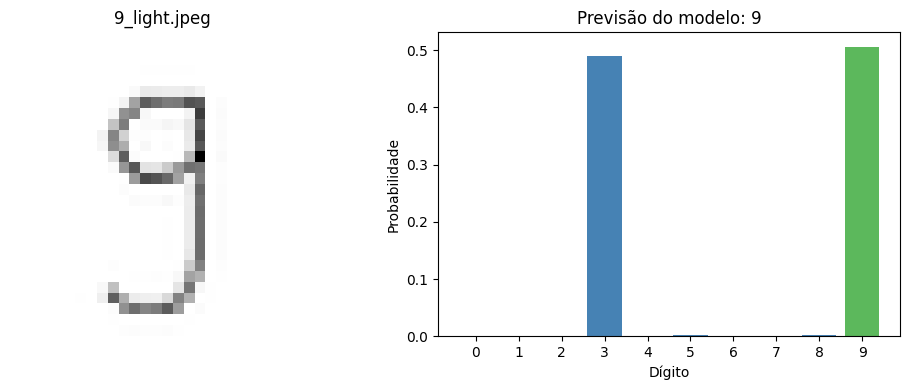

0_dark.png -> previsto como 0 (confiança: 99.94%)


/Users/jenifer/Documents/SCTEC-Mini-Projeto-MD2/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/jenifer/Documents/SCTEC-Mini-Projeto-MD2/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/jenifer/Documents/SCTEC-Mini-Projeto-MD2/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


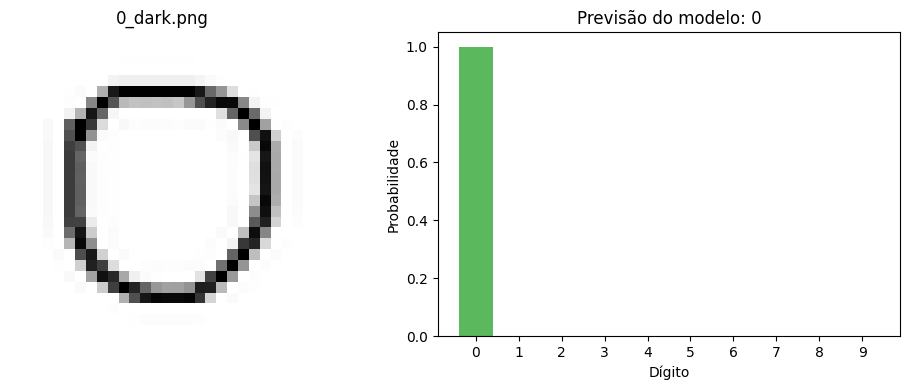

/Users/jenifer/Documents/SCTEC-Mini-Projeto-MD2/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/jenifer/Documents/SCTEC-Mini-Projeto-MD2/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/jenifer/Documents/SCTEC-Mini-Projeto-MD2/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


1_dark.png -> previsto como 1 (confiança: 99.06%)


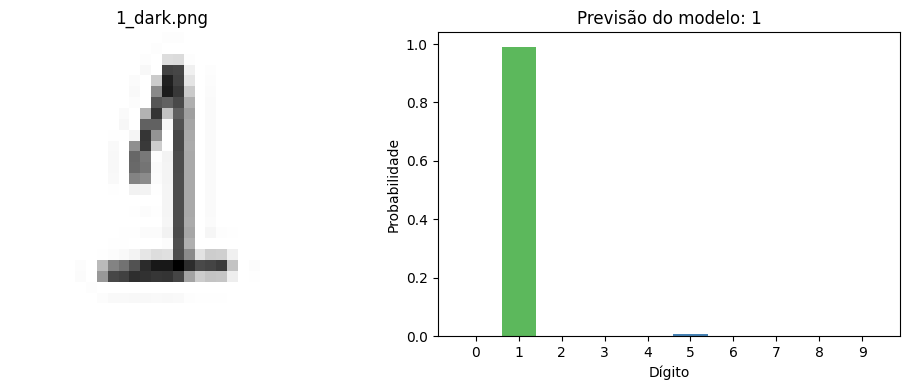

/Users/jenifer/Documents/SCTEC-Mini-Projeto-MD2/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/jenifer/Documents/SCTEC-Mini-Projeto-MD2/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/jenifer/Documents/SCTEC-Mini-Projeto-MD2/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


3_dark.png -> previsto como 3 (confiança: 100.00%)


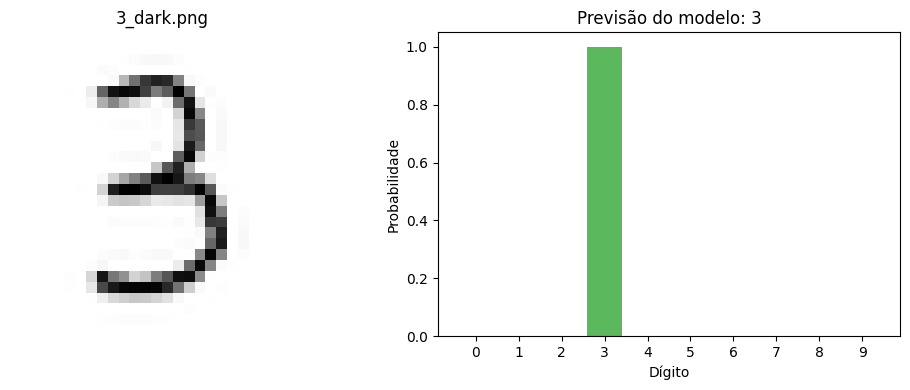

/Users/jenifer/Documents/SCTEC-Mini-Projeto-MD2/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/jenifer/Documents/SCTEC-Mini-Projeto-MD2/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/jenifer/Documents/SCTEC-Mini-Projeto-MD2/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


6_dark.png -> previsto como 6 (confiança: 100.00%)


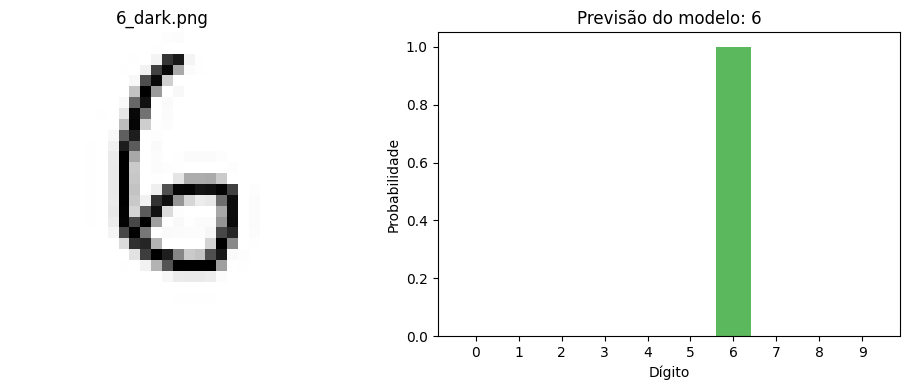

/Users/jenifer/Documents/SCTEC-Mini-Projeto-MD2/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/jenifer/Documents/SCTEC-Mini-Projeto-MD2/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/jenifer/Documents/SCTEC-Mini-Projeto-MD2/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


7_dark.png -> previsto como 7 (confiança: 100.00%)


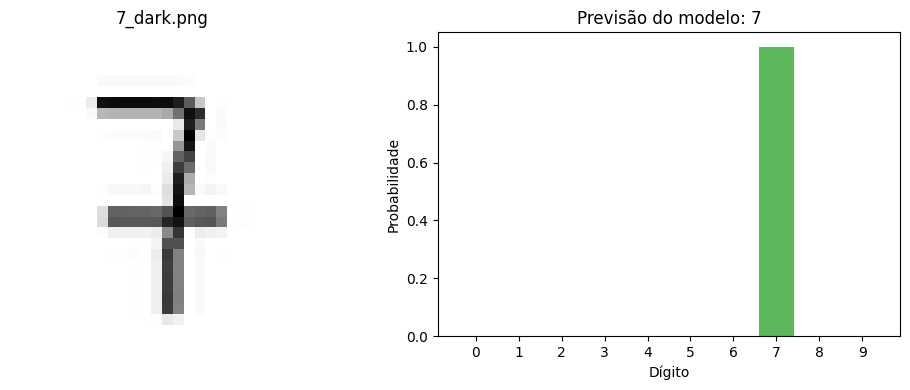

In [24]:
# Percorre as imagens manuscritas, faz o pré-processamento e a previsão com o modelo MLP treinado
for caminho, traco_escuro in caminhos_imagens_proprias:
    imagem_28x28, imagem_normalizada = preprocessar_imagem_propria(caminho, traco_escuro=traco_escuro)

    probabilidades = mlp.predict_proba(imagem_normalizada)[0]
    rotulo_previsto = int(probabilidades.argmax())

    nome_arquivo_origem = os.path.basename(caminho)
    print(f"{nome_arquivo_origem} -> previsto como {rotulo_previsto} " f"(confiança: {probabilidades[rotulo_previsto]:.2%})")

    plot_previsao_digito(
        imagem_28x28, probabilidades,
        titulo=f"{nome_arquivo_origem}",
        nome_arquivo=f'previsao_{os.path.splitext(nome_arquivo_origem)[0]}.png',
    )

Apesar dos acertos, para as imagens da pasta dark a confiança é maior do que para as da pasta light, justamente pelo padrão de imagens já conhecidas. As imagens da pasta light necessitam de um pré-processamento mais refinado, onde aqui pode haver uma confiança menor dependendo do resultado do pré-processamento.